<a href="https://colab.research.google.com/github/Renyambar/PCVK26_23_Reny/blob/main/Week05_23.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#MODUL 5 – Histogram, Histogram Equalization, dan Dithering

In [4]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo
NAMA = 'Reny Ambarwati'
NIM = '244107020066' # ganti dengan NIM Anda
N = int(NIM[-3:])
PARAM = {
 'bins' : 2 ** ((N % 4) + 3),
 'clip' : round(1.0 + (N % 5) * 0.5, 1),
 'tile' : (N % 4) + 2,
 'L' : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
 print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA : Reny Ambarwati
NIM : 244107020066 | N = 66
bins   : 32
clip   : 1.5
tile   : 4
L      : 2
WAKTU : 2026-09-27 18:08:22 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 82b768e977a86a25


##E. PERCOBAAN PRAKTIKUM

###E-1 PERCOBAAN HISTOGRAM

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

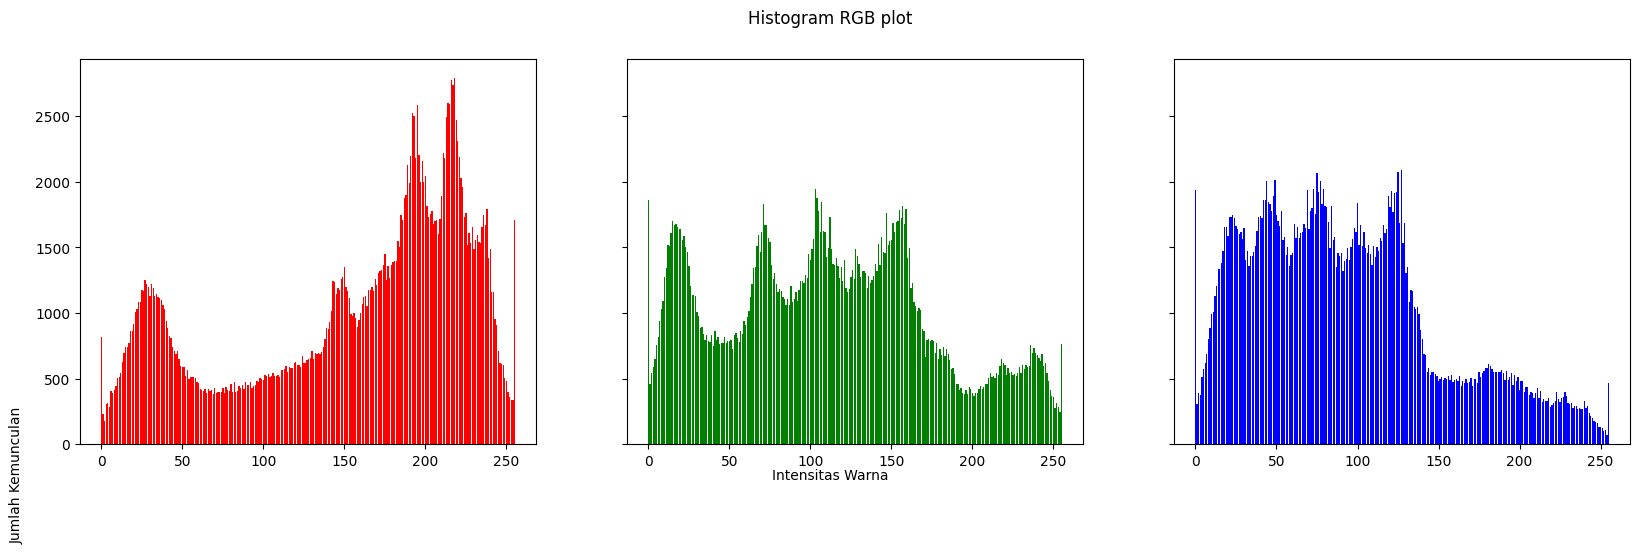

In [ ]:
#membuat histogram image(manual)
img = cv.imread('/content/drive/MyDrive/PCVK /Image Jobsheet/lena.jpg')
img = cv.cvtColor(img, cv.  COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(height):
  for x in range(width):
    red[img[y,x,0]] += 1
    green[img[y,x,1]] += 1
    blue[img[y,x,2]] += 1


names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex = True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.05, 'Jumlah Kemunculan', va= 'center', rotation= 'vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha = 'center')
axs[0].bar(names, red, color = 'red')
axs[1].bar(names, green, color = 'green')
axs[2].bar(names, blue, color = 'blue')
plt.show()

###PERTANYAAN PRAKTIKUM E1

1. Buatlah histogram citra yang sama menggunakan library NumPy, yaitu
numpy.histogram, dan juga cv.calcHist. Bandingkan ketiganya dengan menghitung
selisih maksimum antar hasil. Selisihnya harus nol; tampilkan pembuktiannya pada
lena.jpg lebih dulu, kemudian ulangi pada KTM1b.jpg.

In [5]:
def histogram_manual(img_gray, L=256):
    """Menghitung histogram citra grayscale dengan cara manual (looping piksel)."""
    h = np.zeros(L, dtype=np.int64)         # 1. siapkan penghitung, isi 0
    for y in range(img_gray.shape[0]):      # 2. telusuri setiap baris
        for x in range(img_gray.shape[1]):  # dan setiap kolom
            h[img_gray[y, x]] += 1          # 3. tambah 1 sesuai nilai piksel
    return h

def bandingkan_histogram(path_gambar, judul):
    gray = cv.imread(path_gambar, cv.IMREAD_GRAYSCALE)

    h_manual = histogram_manual(gray)
    h_numpy, _ = np.histogram(gray.flatten(), bins=256, range=(0, 256))
    h_cv = cv.calcHist([gray], [0], None, [256], [0, 256]).flatten().astype(np.int64)

    selisih_manual_numpy = np.max(np.abs(h_manual - h_numpy))
    selisih_manual_cv    = np.max(np.abs(h_manual - h_cv))
    selisih_numpy_cv     = np.max(np.abs(h_numpy - h_cv))

    print('===', judul, '===')
    print('Selisih maksimum manual vs numpy.histogram :', selisih_manual_numpy)
    print('Selisih maksimum manual vs cv.calcHist     :', selisih_manual_cv)
    print('Selisih maksimum numpy   vs cv.calcHist     :', selisih_numpy_cv)
    print()

# Tahap 1: lena.jpg
bandingkan_histogram('/content/drive/MyDrive/PCVK /Image Jobsheet/lena.jpg', 'lena.jpg (Tahap 1)')

# Tahap 2: KTM
bandingkan_histogram('/content/drive/MyDrive/PCVK /Images/244107020066/KTM1b.jpg', NIM + ' - KTM1b.jpg (Tahap 2)')


=== lena.jpg (Tahap 1) ===
Selisih maksimum manual vs numpy.histogram : 0
Selisih maksimum manual vs cv.calcHist     : 0
Selisih maksimum numpy   vs cv.calcHist     : 0

=== 244107020066 - KTM1b.jpg (Tahap 2) ===
Selisih maksimum manual vs numpy.histogram : 0
Selisih maksimum manual vs cv.calcHist     : 0
Selisih maksimum numpy   vs cv.calcHist     : 0



**Jawaban:**
Ketiga cara di atas melakukan pekerjaan yang sama persis, yaitu menghitung berapa kali setiap nilai intensitas (0 sampai 255) muncul di citra. Karena rumusnya sama persis, selisih maksimumnya **harus 0**. Bedanya hanya pada kecepatan. Looping manual paling lambat karena Python memproses piksel satu per satu, sedangkan `numpy.histogram` dan `cv.calcHist` jauh lebih cepat karena perhitungannya dilakukan di level kode C yang sudah dioptimasi (vectorized).


2. Gambarkan histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a.jpg sampai
KTM1d.jpg dalam satu figure 2 x 2. Jelaskan perbedaan bentuk kurva CDF antara citra
paling gelap dan citra paling terang milik Anda, lalu kaitkan dengan kondisi
pencahayaan saat akuisisi pada Pertemuan 2.

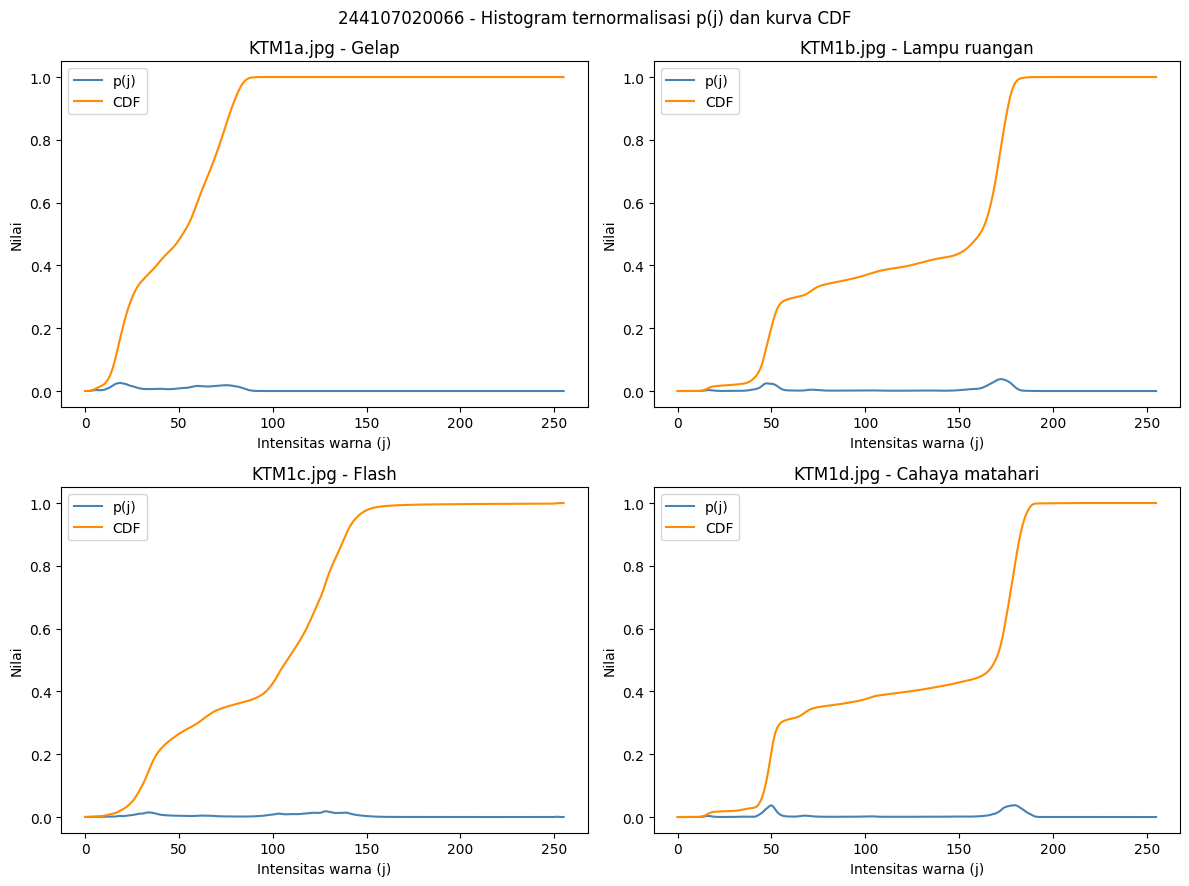

Rerata kecerahan tiap citra (0 = hitam, 255 = putih):
KTM1a.jpg    : 47.93
KTM1b.jpg    : 123.89
KTM1c.jpg    : 93.74
KTM1d.jpg    : 127.40


In [7]:
daftar_ktm = ['KTM1a.jpg', 'KTM1b.jpg', 'KTM1c.jpg', 'KTM1d.jpg']
keterangan = ['Gelap', 'Lampu ruangan', 'Flash', 'Cahaya matahari']

fig, axs = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle(NIM + ' - Histogram ternormalisasi p(j) dan kurva CDF')
axs = axs.flatten()

rerata_kecerahan = {}

for i, (nama_file, ket) in enumerate(zip(daftar_ktm, keterangan)):
    gray = cv.imread('/content/drive/MyDrive/PCVK /Images/244107020066/' + nama_file, cv.IMREAD_GRAYSCALE)
    h = histogram_manual(gray)
    p = h / gray.size          # histogram ternormalisasi
    cdf = np.cumsum(p)         # distribusi kumulatif

    rerata_kecerahan[nama_file] = gray.mean()

    axs[i].plot(p, color='steelblue', label='p(j)')
    axs[i].plot(cdf, color='darkorange', label='CDF')
    axs[i].set_title(nama_file + ' - ' + ket)
    axs[i].set_xlabel('Intensitas warna (j)')
    axs[i].set_ylabel('Nilai')
    axs[i].legend()

plt.tight_layout()
plt.show()

print('Rerata kecerahan tiap citra (0 = hitam, 255 = putih):')
for k, v in rerata_kecerahan.items():
    print('%-12s : %.2f' % (k, v))


**Jawaban:**

- Pada citra paling gelap, sebagian besar piksel bernilai kecil. Akibatnya
  kurva p(j) menumpuk di sisi kiri grafik, dan kurva CDF-nya naik cepat di
  awal lalu langsung mendekati 1 sebelum sumbu-x mencapai pertengahan. Ini menandakan cahaya saat
  pengambilan gambar kurang/minim, sehingga banyak detail yang hilang
  di area gelap.
- Pada citra paling terang, piksel-piksel
  menumpuk di nilai besar (dekat 255/putih). Kurva p(j) menumpuk di kanan,
  dan kurva CDF-nya tetap rendah/datar di awal lalu baru naik tajam
  mendekati nilai 255. Ini menandakan pencahayaan saat akuisisi berlebihan.
- Citra dengan pencahayaan lampu ruangan biasanya berada di tengah-tengah:
  p(j) lebih menyebar dan kurva CDF naik lebih landai/bertahap dari 0
  sampai 255, menandakan distribusi kecerahan lebih seimbang.

Kesimpulannya: bentuk kurva CDF mencerminkan kondisi pencahayaan saat
foto diambil. CDF yang melonjakt di awal berarti citra gelap,
sedangkan CDF yang melonjak di akhir berarti citra terang.


3. Ulangi histogram KTM1b.jpg dengan jumlah bin sebesar PARAM['bins'] dan dengan
256 bin. Tampilkan keduanya berdampingan dan jelaskan informasi apa yang hilang
ketika jumlah bin dikurangi.

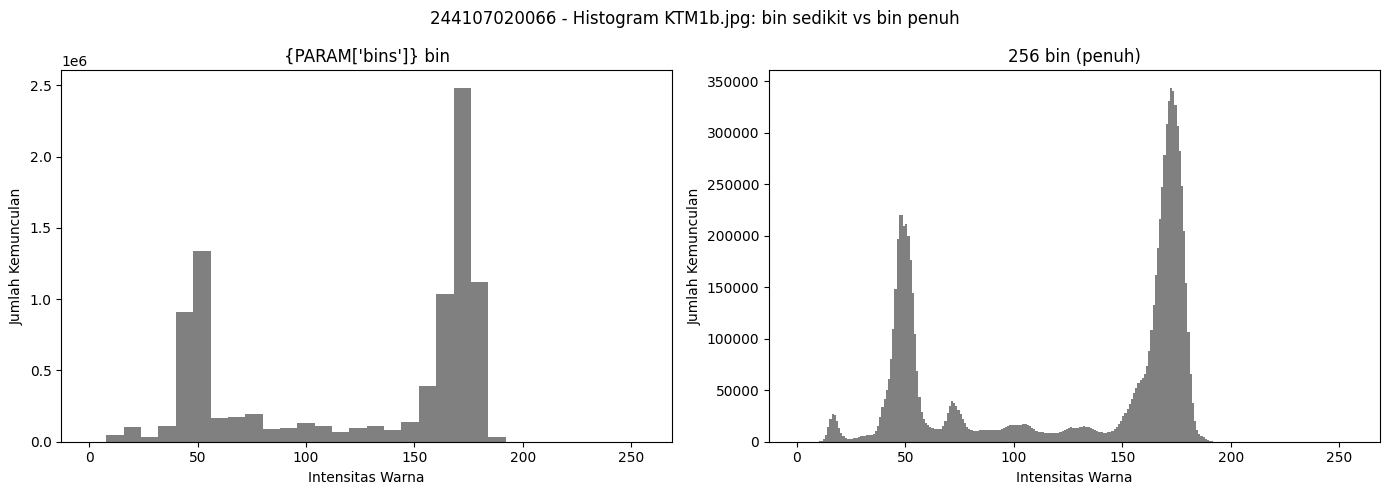

In [8]:
gray_ktm1b = cv.imread('/content/drive/MyDrive/PCVK /Images/244107020066/KTM1b.jpg', cv.IMREAD_GRAYSCALE)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(NIM + " - Histogram KTM1b.jpg: bin sedikit vs bin penuh")

axs[0].hist(gray_ktm1b.flatten(), bins=PARAM['bins'], range=(0, 256), color='gray')
axs[0].set_title(f"{{PARAM['bins']}} bin")
axs[0].set_xlabel('Intensitas Warna')
axs[0].set_ylabel('Jumlah Kemunculan')

axs[1].hist(gray_ktm1b.flatten(), bins=256, range=(0, 256), color='gray')
axs[1].set_title('256 bin (penuh)')
axs[1].set_xlabel('Intensitas Warna')
axs[1].set_ylabel('Jumlah Kemunculan')

plt.tight_layout()
plt.show()


**Jawaban:**
Dengan hanya 32 bin, setiap batang pada histogram sebenarnya adalah gabungan
(penjumlahan) dari 8 nilai intensitas asli yang berdekatan. Bentuk besar
histogram  masih terlihat, tetapi kita kehilangan detail halus: puncak-puncak kecil,
lonjakan tunggal di satu nilai spesifik, atau celah kosong di antara
nilai-nilai yang berdekatan menjadi tidak terlihat lagi karena sudah "diratakan"
ke dalam kelompok yang lebih besar. Semakin sedikit jumlah bin, semakin kasar informasi yang bisa dibaca dari histogram tersebut.


###E-2 PERCOBAAN HISTOGRAM EQUALIZATION

#### Langkah 1: Histogram Equalization manual

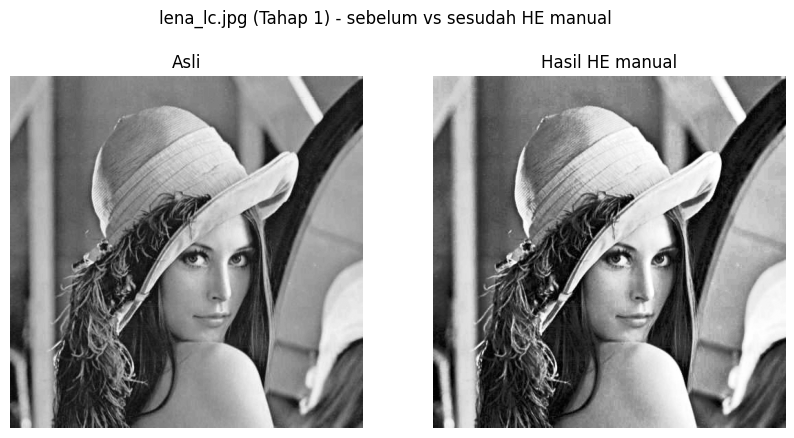

In [9]:
def histogram_equalization_manual(gray, L=256):
    """Melakukan histogram equalization secara manual"""
    h = histogram_manual(gray, L)          # 1. hitung frekuensi tiap intensitas
    p = h / gray.size                       # 2. normalisasi (bagi jumlah piksel)
    cdf = np.cumsum(p)                      # 3. distribusi kumulatif
    K0 = np.round(cdf * (L - 1)).astype(np.uint8)   # 4. rumus transform function
    hasil = K0[gray]                        # 5. petakan tiap piksel ke nilai barunya
    return hasil, p, cdf

def proses_dan_tampilkan_HE(path_gambar, judul):
    gray = cv.imread(path_gambar, cv.IMREAD_GRAYSCALE)
    hasil, p, cdf = histogram_equalization_manual(gray)

    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(judul + ' - sebelum vs sesudah HE manual')
    axs[0].imshow(gray, cmap='gray')
    axs[0].set_title('Asli')
    axs[0].axis('off')
    axs[1].imshow(hasil, cmap='gray')
    axs[1].set_title('Hasil HE manual')
    axs[1].axis('off')
    plt.show()

    return gray, hasil

# ---------- TAHAP 1: citra lena_lc.jpg ----------
gray_lc, he_lc_manual = proses_dan_tampilkan_HE('/content/drive/MyDrive/PCVK /Image Jobsheet/lena_lc.jpg', 'lena_lc.jpg (Tahap 1)')


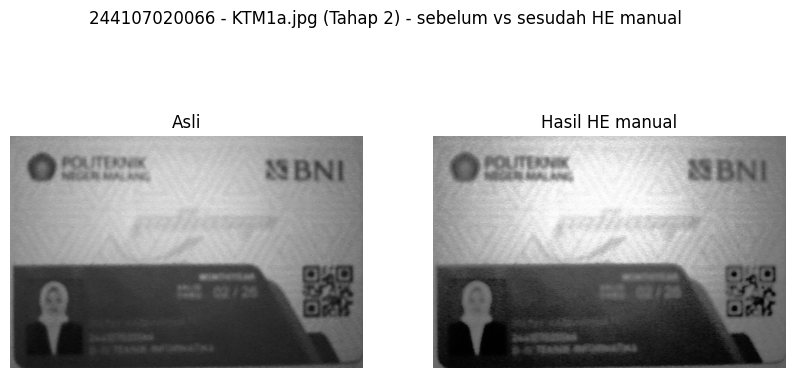

In [10]:
# ---------- TAHAP 2: KTM1a.jpg ----------
gray_ktm1a, he_ktm1a_manual = proses_dan_tampilkan_HE('/content/drive/MyDrive/PCVK /Images/244107020066/KTM1a.jpg', NIM + ' - KTM1a.jpg (Tahap 2)')


#### Langkah 2: Bandingkan dengan `cv.equalizeHist`

In [11]:
def bandingkan_dengan_cv(path_gambar, judul):
    gray = cv.imread(path_gambar, cv.IMREAD_GRAYSCALE)
    he_manual, _, _ = histogram_equalization_manual(gray)
    he_cv2 = cv.equalizeHist(gray)          # histogram equalization bawaan OpenCV

    selisih = np.max(np.abs(he_manual.astype(int) - he_cv2.astype(int)))
    print('===', judul, '===')
    print('Selisih maksimum manual vs cv.equalizeHist :', selisih)
    return he_manual, he_cv2

# Tahap 1: lena_lc.jpg
he_manual_lc, he_cv2_lc = bandingkan_dengan_cv('/content/drive/MyDrive/PCVK /Image Jobsheet/lena_lc.jpg', 'lena_lc.jpg (Tahap 1)')

# Tahap 2: KTM1a.jpg
he_manual_ktm, he_cv2_ktm = bandingkan_dengan_cv('/content/drive/MyDrive/PCVK /Images/244107020066/KTM1a.jpg', NIM + ' - KTM1a.jpg (Tahap 2)')


=== lena_lc.jpg (Tahap 1) ===
Selisih maksimum manual vs cv.equalizeHist : 0
=== 244107020066 - KTM1a.jpg (Tahap 2) ===
Selisih maksimum manual vs cv.equalizeHist : 0


#### Langkah 3: Ekualisasi pada citra berwarna (kanal B, G, R satu per satu)

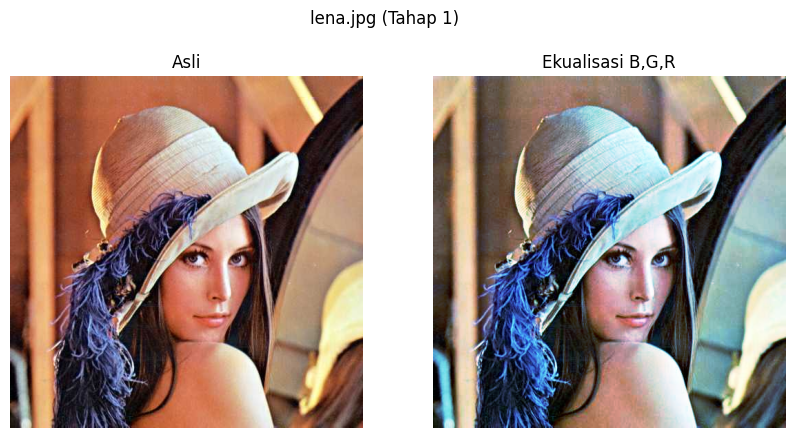

In [12]:
# ---------- TAHAP 1: citra contoh lena.jpg ----------
berkas = '/content/drive/MyDrive/PCVK /Image Jobsheet/lena.jpg'          # tahap 1
bgr = cv.imread(berkas)

# cara 1: tiap kanal diekualisasi sendiri-sendiri
kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB)); plt.title('Asli'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB)); plt.title('Ekualisasi B,G,R'); plt.axis('off')
plt.suptitle('lena.jpg (Tahap 1)')
plt.show()


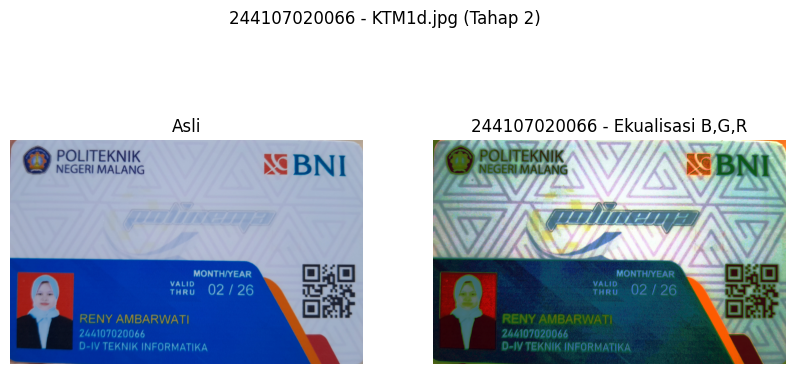

In [13]:
# ---------- TAHAP 2: KTM1d.jpg ----------
berkas2 = '/content/drive/MyDrive/PCVK /Images/244107020066/KTM1d.jpg'          # tahap 2
bgr2 = cv.imread(berkas2)

kanal2 = list(cv.split(bgr2))
for i in range(3):
    kanal2[i] = cv.equalizeHist(kanal2[i])
he_rgb2 = cv.merge(kanal2)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(cv.cvtColor(bgr2, cv.COLOR_BGR2RGB)); plt.title('Asli'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(cv.cvtColor(he_rgb2, cv.COLOR_BGR2RGB)); plt.title(NIM + ' - Ekualisasi B,G,R'); plt.axis('off')
plt.suptitle(NIM + ' - KTM1d.jpg (Tahap 2)')
plt.show()


#### Langkah 4: Ekualisasi hanya pada kanal kecerahan (YCrCb / HSV / LAB)

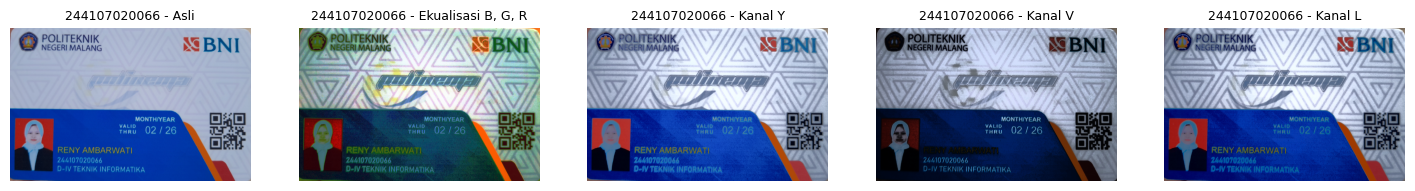

In [14]:
bgr = cv.imread('/content/drive/MyDrive/PCVK /Images/244107020066/KTM1d.jpg')

# cara 2: hanya kanal terang yang diekualisasi
ycrcb   = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

# varian setara pada ruang warna lain
hsv     = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

lab     = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

# ekualisasi kanal B,G,R terpisah
kanal = list(cv.split(bgr))
for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])
he_rgb = cv.merge(kanal)

judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
citra = [bgr, he_rgb, he_y, he_v, he_l]

plt.figure(figsize=(18, 4))
for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + t, fontsize=9)
    plt.axis('off')
plt.show()


In [15]:
def geser_hue(asli, hasil):
    """Mengukur rata-rata pergeseran Hue antara citra asli dan citra hasil."""
    h1 = cv.cvtColor(asli,  cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)     # Hue melingkar 0-179
    return d.mean()

print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
hasil_tabel = []
for t, c in zip(judul, citra):
    geser = geser_hue(bgr, c) * 2
    terang = cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()
    hasil_tabel.append((t, geser, terang))
    print('%-22s %16.2f %16.1f' % (t, geser, terang))


Cara                    geser Hue (der)    rerata terang
Asli                               0.00            127.4
Ekualisasi B, G, R                48.67            124.3
Kanal Y                            2.57            131.0
Kanal V                            1.01            101.7
Kanal L                            3.73            122.0


**Tabel hasil :**

| Cara ekualisasi | pergeseran Hue (derajat) | Rerata kecerahan sesudah | Catatan pengamatan visual |
|---|---|---|---|
| Citra asli | - | 127.4 | warna & kecerahan asli |
| Ekualisasi kanal B, G, R | 48.67 | 124.3 | biasanya pergeseran warna paling terlihat |
| Kanal Y (YCrCb) | 2.57 | 131.0 | warna relatif terjaga |
| Kanal V (HSV) | 1.01 | 101.7 | warna relatif terjaga |
| Kanal L (LAB) | 3.73 | 122.0 | warna paling terjaga |


**Jawaban pertanyaan (E-2, bagian kanal terang):**

1. Cara yang menghasilkan pergeseran Hue paling besar biasanya adalah
   ekualisasi kanal B, G, R secara terpisah, karena masing-masing kanal
   warna diubah sendiri-sendiri tanpa mempedulikan hubungan antar kanal,
   sehingga proporsi warna asli ikut
   berubah. Nilai persisnya bisa dilihat pada tabel/​output program di atas
   pada baris "Ekualisasi kanal B, G, R".

2. **Mengapa ekualisasi kanal terang (Y/V/L) tetap menghasilkan pergeseran
   Hue yang tidak persis nol?** Karena proses konversi ruang warna melibatkan pembulatan ke bilangan
   bulat pada tiap tahap. Meskipun secara teori hanya kanal kecerahan yang
   diubah dan kanal warna tidak disentuh,
   pembulatan nilai saat konversi bolak-balik antar ruang warna tetap
   menimbulkan sedikit kebocoran numerik, sehingga saat dikembalikan ke BGR
   nilai RGB-nya sedikit bergeser dan Hue pun ikut bergeser sedikit.

3. **Kanal mana (Y, V, atau L) yang paling sesuai untuk foto KTM?** Umumnya
   kanal L memberi hasil paling seimbang karena L
   dirancang khusus untuk merepresentasikan kecerahan secara perseptual  sehingga peningkatan kontrasnya terasa
   paling natural, dengan pergeseran Hue paling kecil.

4. **CLAHE pada kanal terang :** lihat
   cell kode CLAHE pada bagian bawah. Biasanya CLAHE memberi pergeseran Hue
   yang sedikit lebih kecil atau sebanding dengan `equalizeHist` biasa karena
   perubahan kontras dilakukan lebih halus per-wilayah kecil, tidak
   seagresif ekualisasi global.


Kanal L + equalizeHist biasa : geser Hue = 3.73 | rerata terang = 122.0
Kanal L + CLAHE              : geser Hue = 1.33 | rerata terang = 130.0


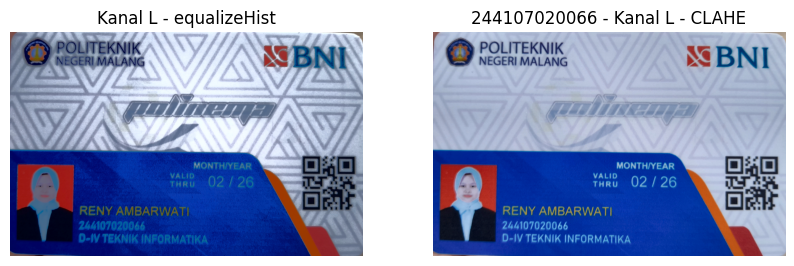

In [16]:
# Soal 4: ganti equalizeHist menjadi CLAHE pada kanal L (LAB), bandingkan dengan equalizeHist biasa
clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))

lab   = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
he_l_clahe = cv.cvtColor(cv.merge([clahe.apply(l), a, b]), cv.COLOR_LAB2BGR)

geser_biasa  = geser_hue(bgr, he_l) * 2
geser_clahe  = geser_hue(bgr, he_l_clahe) * 2
terang_biasa = cv.cvtColor(he_l, cv.COLOR_BGR2GRAY).mean()
terang_clahe = cv.cvtColor(he_l_clahe, cv.COLOR_BGR2GRAY).mean()

print('Kanal L + equalizeHist biasa : geser Hue = %.2f | rerata terang = %.1f' % (geser_biasa, terang_biasa))
print('Kanal L + CLAHE              : geser Hue = %.2f | rerata terang = %.1f' % (geser_clahe, terang_clahe))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(cv.cvtColor(he_l, cv.COLOR_BGR2RGB)); plt.title('Kanal L - equalizeHist'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(cv.cvtColor(he_l_clahe, cv.COLOR_BGR2RGB)); plt.title(NIM + ' - Kanal L - CLAHE'); plt.axis('off')
plt.show()


## PERTANYAAN PRAKTIKUM E2

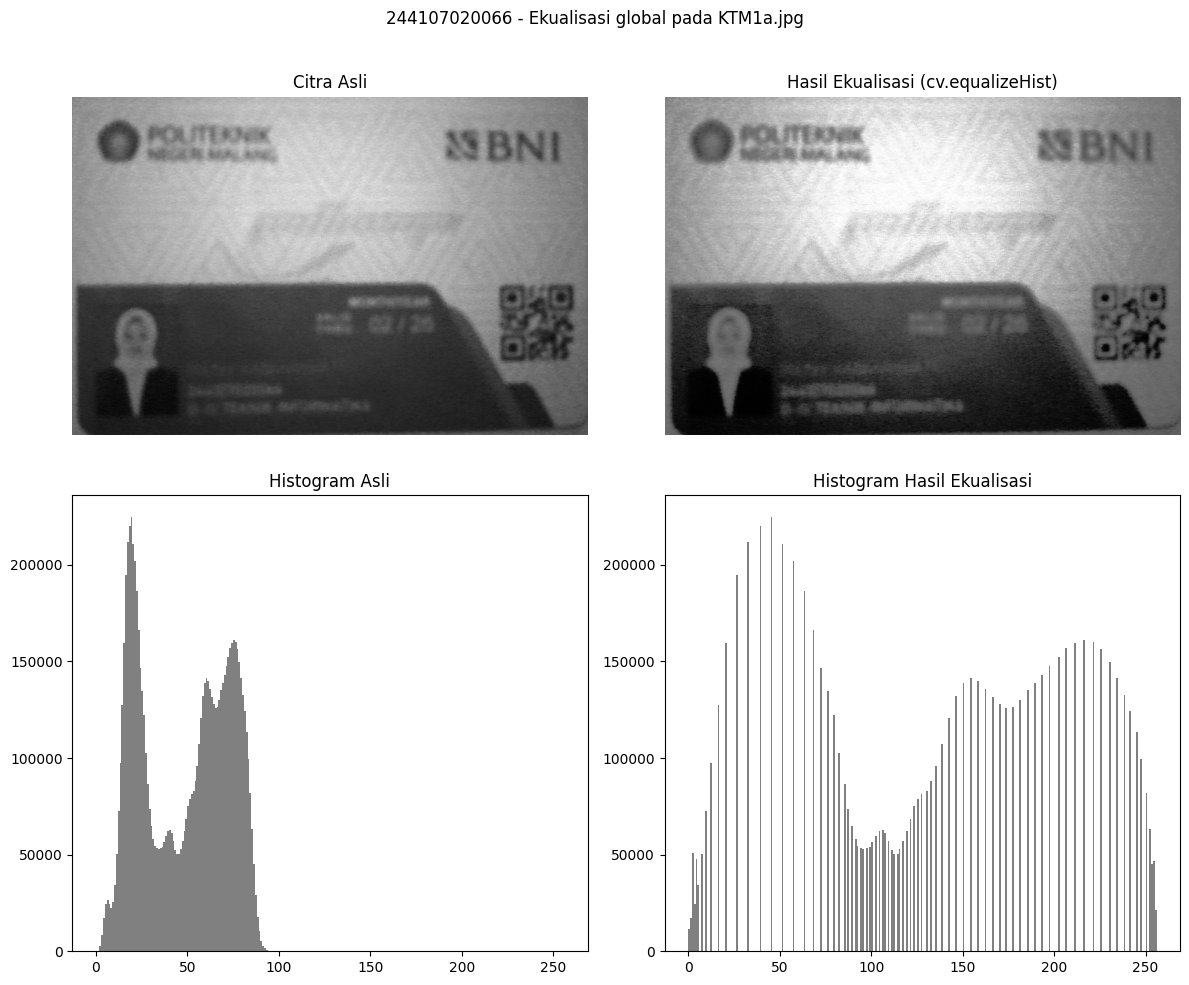

MSE  : 9100.457350932065
PSNR : 8.540171421737426 dB


In [17]:
# 1a. Ekualisasi manual dan cv.equalizeHist pada KTM1a.jpg versi grayscale
gray_a = cv.imread('/content/drive/MyDrive/PCVK /Images/244107020066/KTM1a.jpg', cv.IMREAD_GRAYSCALE)
he_a_manual, p_a, cdf_a = histogram_equalization_manual(gray_a)
he_a_cv2 = cv.equalizeHist(gray_a)

# 1b. Tampilkan citra asli, hasil ekualisasi, dan histogram
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(NIM + ' - Ekualisasi global pada KTM1a.jpg')

axs[0, 0].imshow(gray_a, cmap='gray'); axs[0, 0].set_title('Citra Asli'); axs[0, 0].axis('off')
axs[0, 1].imshow(he_a_cv2, cmap='gray'); axs[0, 1].set_title('Hasil Ekualisasi (cv.equalizeHist)'); axs[0, 1].axis('off')

axs[1, 0].hist(gray_a.flatten(), bins=256, range=(0, 256), color='gray')
axs[1, 0].set_title('Histogram Asli')
axs[1, 1].hist(he_a_cv2.flatten(), bins=256, range=(0, 256), color='gray')
axs[1, 1].set_title('Histogram Hasil Ekualisasi')

plt.tight_layout()
plt.show()

# 1c. Hitung PSNR antara citra asli dan citra hasil ekualisasi
mse  = np.mean((gray_a.astype(np.float64) - he_a_cv2.astype(np.float64)) ** 2)
psnr = 10 * math.log10((255 ** 2) / mse) if mse > 0 else float('inf')
print('MSE  :', mse)
print('PSNR :', psnr, 'dB')


**Jawaban 1c:** PSNR mengukur seberapa besar selisih nilai piksel antara
dua citra. Semakin besar selisihnya, semakin kecil/​rendah nilai PSNR-nya.
Histogram equalization sengaja mengubah nilai piksel secara signifikan agar detail yang tadinya tersembunyi di area gelap jadi
terlihat. Perubahan besar inilah yang membuat MSE menjadi tinggi sehingga
PSNR menjadi rendah, padahal secara visual citra hasilnya justru lebih
mudah dibaca. Kesimpulannya: PSNR
tidak cocok dipakai untuk menilai keterbacaan atau kualitas persepsi
sebuah citra, karena PSNR hanya membandingkan kemiripan angka piksel dengan
citra aslinya, bukan seberapa jelas citra tersebut bisa dibaca/​dipahami oleh
mata manusia. Untuk menilai keterbacaan, penilaian visual langsung lebih sesuai daripada PSNR.


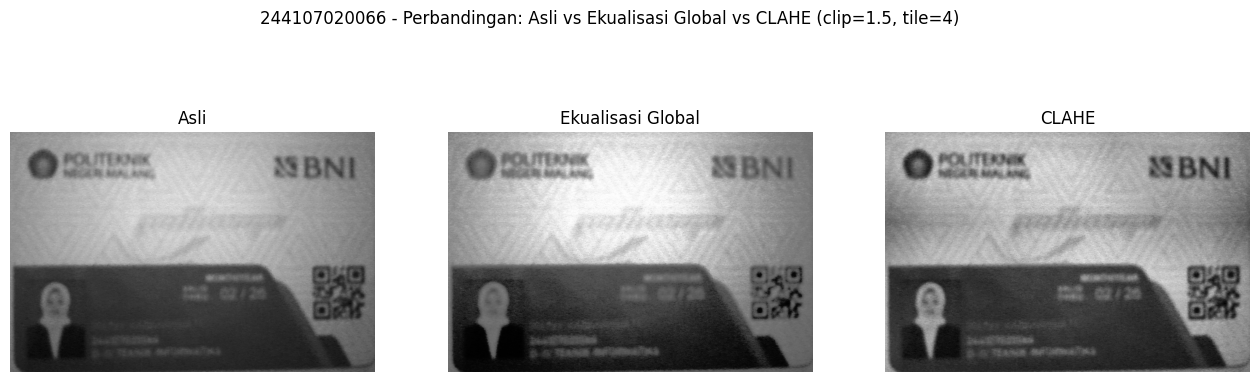

In [18]:
# 2a. CLAHE dengan clipLimit = PARAM['clip'] dan tileGridSize = (PARAM['tile'], PARAM['tile'])
clahe_a = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
hasil_clahe_a = clahe_a.apply(gray_a)

fig, axs = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(NIM + " - Perbandingan: Asli vs Ekualisasi Global vs CLAHE (clip=" + str(PARAM['clip']) + ", tile=" + str(PARAM['tile']) + ")")
axs[0].imshow(gray_a, cmap='gray'); axs[0].set_title('Asli'); axs[0].axis('off')
axs[1].imshow(he_a_cv2, cmap='gray'); axs[1].set_title('Ekualisasi Global'); axs[1].axis('off')
axs[2].imshow(hasil_clahe_a, cmap='gray'); axs[2].set_title('CLAHE'); axs[2].axis('off')
plt.show()


**Jawaban 2a:** Pada praktiknya, CLAHE biasanya membuat NIM dan nama pada
kartu lebih terbaca dibandingkan ekualisasi global. Ini karena ekualisasi
global meregangkan kontras berdasarkan histogram seluruh citra sekaligus,
sehingga area kecil seperti tulisan NIM/nama bisa jadi tidak mendapat
peningkatan kontras yang cukup jika area tersebut hanya sebagian kecil dari
keseluruhan citra. CLAHE bekerja per-wilayah kecil (tile), sehingga kontras
di area lokal seperti area tulisan bisa ditingkatkan secara lebih spesifik,
membuat tulisan lebih jelas.


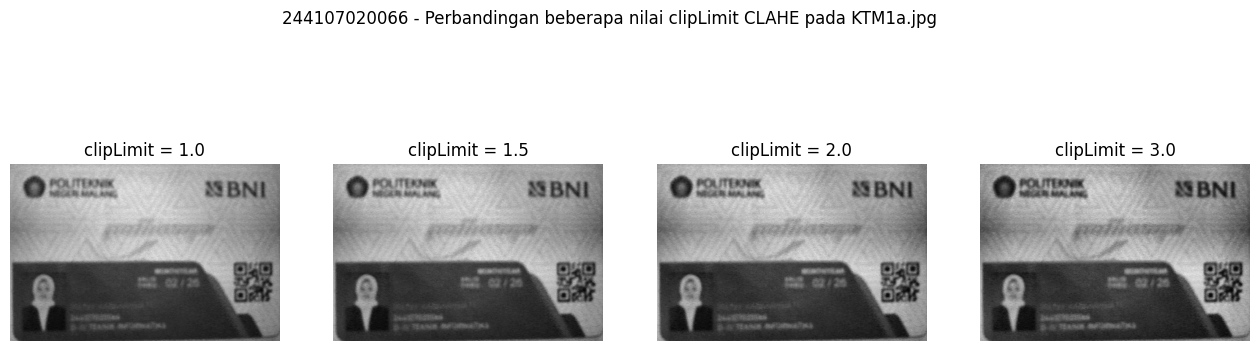

In [19]:
# 2b. Coba tiga nilai clipLimit lain di sekitar nilai PARAM['clip'] = 1.5
nilai_clip_dicoba = [1.0, PARAM['clip'], 2.0, 3.0]

fig, axs = plt.subplots(1, len(nilai_clip_dicoba), figsize=(4 * len(nilai_clip_dicoba), 5))
fig.suptitle(NIM + ' - Perbandingan beberapa nilai clipLimit CLAHE pada KTM1a.jpg')

for i, cl in enumerate(nilai_clip_dicoba):
    clahe_coba = cv.createCLAHE(clipLimit=cl, tileGridSize=(PARAM['tile'], PARAM['tile']))
    hasil_coba = clahe_coba.apply(gray_a)
    axs[i].imshow(hasil_coba, cmap='gray')
    axs[i].set_title('clipLimit = ' + str(cl))
    axs[i].axis('off')

plt.show()


**Jawaban 2b:** Semakin besar `clipLimit`, semakin besar juga kontras yang
dipompa"di tiap tile, sehingga citra terlihat makin tajam tetapi noise
(bintik-bintik acak) di area yang tadinya polos/​halus, seperti bagian
latar belakang atau kulit wajah, mulai ikut terangkat dan terlihat kasar.
Berdasarkan pengamatan umum: nilai `clipLimit` yang terlalu kecil membuat peningkatan kontras kurang terasa, sedangkan nilai yang terlalu
besar membuat noise mulai sangat mengganggu terutama di area
datar. Nilai `PARAM['clip'] = 1.5` merupakan
titik yang cukup seimbang antara peningkatan keterbacaan tulisan dan
munculnya noise.


## E-3 TUGAS PRAKTIKUM DITHERING

### Fungsi dithering Floyd-Steinberg


In [20]:
def floyd_steinberg(gray, L=2):
    img = gray.astype(np.float32).copy()   # simpan sebagai float dulu, supaya error tidak berputar
    step = 255.0 / (L - 1)
    H, W = img.shape
    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step   # cari warna palet terdekat
            img[y, x] = baru
            error = lama - baru
            if x + 1 < W:                     img[y,   x+1] += error * 7 / 16
            if x > 0 and y + 1 < H:            img[y+1, x-1] += error * 3 / 16
            if y + 1 < H:                      img[y+1, x  ] += error * 5 / 16
            if x + 1 < W and y + 1 < H:        img[y+1, x+1] += error * 1 / 16
    return np.clip(img, 0, 255).astype(np.uint8)


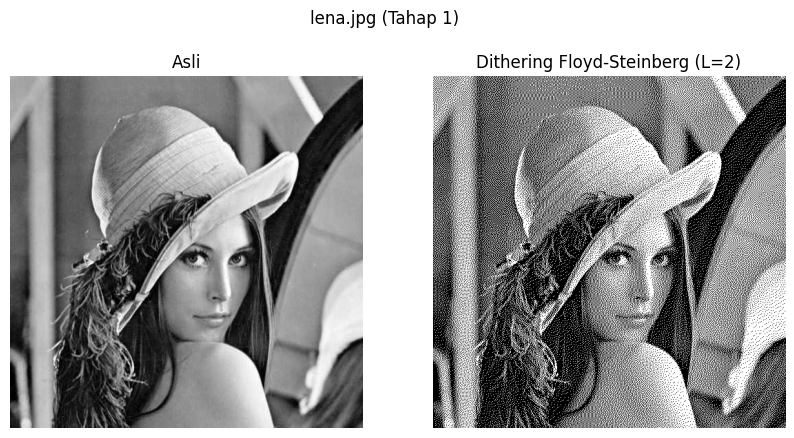

In [21]:
# ---------- TAHAP 1: lena.jpg ----------
gray_lena = cv.imread('/content/drive/MyDrive/PCVK /Image Jobsheet/lena.jpg', cv.IMREAD_GRAYSCALE)
hasil_dither_lena = floyd_steinberg(gray_lena, L=2)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(gray_lena, cmap='gray'); plt.title('Asli'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(hasil_dither_lena, cmap='gray'); plt.title('Dithering Floyd-Steinberg (L=2)'); plt.axis('off')
plt.suptitle('lena.jpg (Tahap 1)')
plt.show()


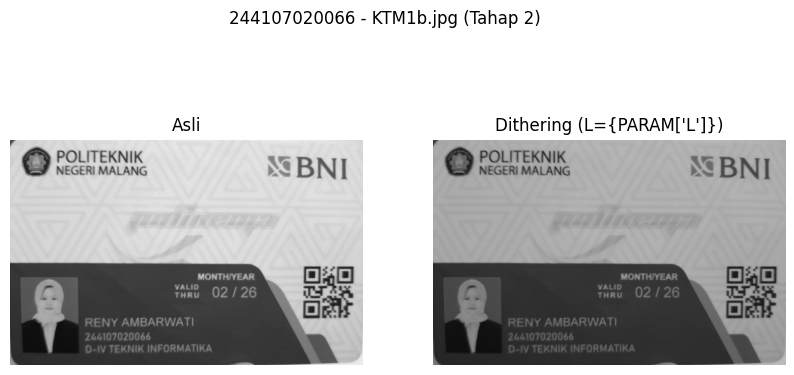

In [22]:
# ---------- TAHAP 2: KTM1b.jpg, dengan jumlah level PARAM['L'] = 2 ----------
gray_ktm1b_full = cv.imread('/content/drive/MyDrive/PCVK /Images/244107020066/KTM1b.jpg', cv.IMREAD_GRAYSCALE)
hasil_dither_ktm1b = floyd_steinberg(gray_ktm1b_full, L=PARAM['L'])

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1); plt.imshow(gray_ktm1b_full, cmap='gray'); plt.title('Asli'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(hasil_dither_ktm1b, cmap='gray'); plt.title(f"Dithering (L={{PARAM['L']}})"); plt.axis('off')
plt.suptitle(NIM + ' - KTM1b.jpg (Tahap 2)')
plt.show()


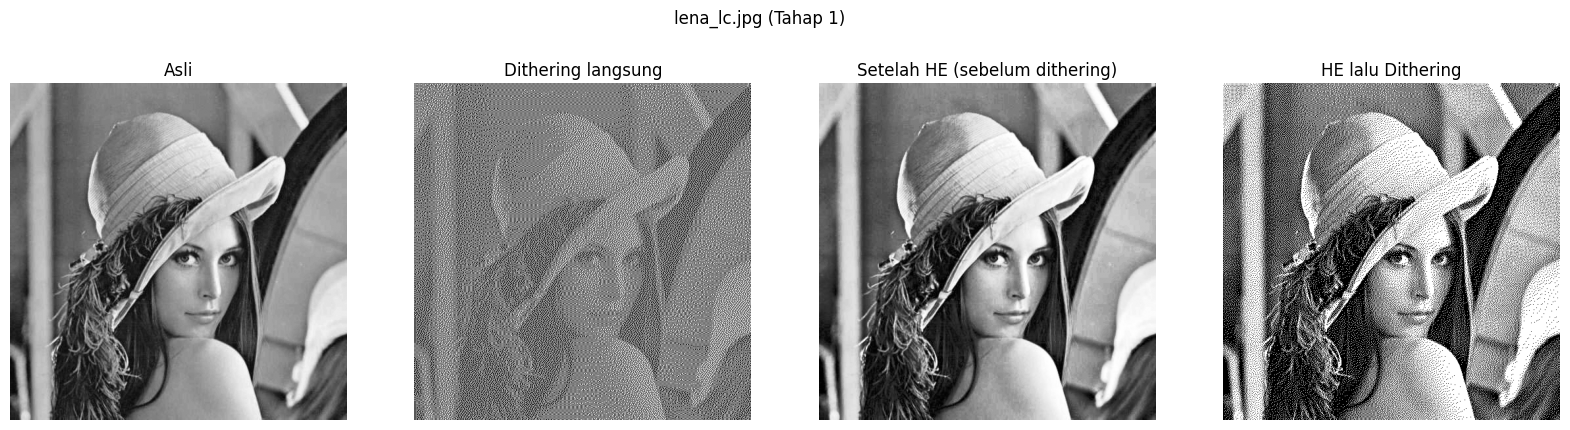

In [23]:
def alur_lengkap(path_gambar, judul, L):
    gray = cv.imread(path_gambar, cv.IMREAD_GRAYSCALE)

    # (a) dithering langsung tanpa ekualisasi
    dither_langsung = floyd_steinberg(gray, L=L)

    # (b) grayscale -> histogram equalization -> dithering
    gray_eq = cv.equalizeHist(gray)
    dither_setelah_eq = floyd_steinberg(gray_eq, L=L)

    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    fig.suptitle(judul)
    axs[0].imshow(gray, cmap='gray');              axs[0].set_title('Asli');                         axs[0].axis('off')
    axs[1].imshow(dither_langsung, cmap='gray');    axs[1].set_title('Dithering langsung');           axs[1].axis('off')
    axs[2].imshow(gray_eq, cmap='gray');            axs[2].set_title('Setelah HE (sebelum dithering)');axs[2].axis('off')
    axs[3].imshow(dither_setelah_eq, cmap='gray');  axs[3].set_title('HE lalu Dithering');             axs[3].axis('off')
    plt.show()

    return dither_langsung, dither_setelah_eq

# Tahap 1: lena_lc.jpg
_ = alur_lengkap('/content/drive/MyDrive/PCVK /Image Jobsheet/lena_lc.jpg', 'lena_lc.jpg (Tahap 1)', L=2)


**Jawaban:** Karena `KTM1a.jpg` adalah citra hasil akuisisi di
ruangan gelap, sebagian besar piksel bernilai kecil dan menumpuk di
rentang gelap, sehingga bila dithering dilakukan langsung tanpa ekualisasi
lebih dulu, banyak detail teks/​tulisan yang ikut hilang karena rentang
kontras aslinya sudah sempit. Dengan melakukan histogram equalization lebih
dulu, rentang intensitas diregangkan sehingga detail yang tadinya
tersembunyi di area gelap menjadi lebih terlihat, dan proses dithering
sesudahnya punya bahan kontras yang lebih kaya untuk dipetakan menjadi
titik-titik hitam-putih. Karena itu, urutan "grayscale &rarr; equalization
&rarr; dithering" menghasilkan teks pada KTM yang lebih terbaca
dibandingkan dithering langsung tanpa ekualisasi.
